# 🌊 Tutorial: Differentiable Ocean Dynamics with Reactant.jl
## 1. Introduction: Why Differentiable Modeling?
Traditionally, ocean models are "black boxes." We put parameters in, and we get a simulation out. But if we want to know "How does the wind in the Drake Passage affect the heat in the North Atlantic?", we usually have to run thousands of simulations.

Cue in the Adjoint Method (Automatic Differentiation):By using Reactant.jl and Enzyme.jl, we transform our simulation into a mathematical function that we can differentiate.
- Forward Pass: The ocean flows (Physics).
- Adjoint Pass: The sensitivities flow backward (Gradients).

## 2. The Physical Setup
Our simulation represents a Reentrant Channel.
- Architecture: ReactantState() — We are running on an NVIDIA Tesla T4 using XLA (Accelerated Linear Algebra).
- Grid: ImmersedBoundaryGrid — This allows us to simulate complex bottom topography (the "bumps" on the ocean floor) that trigger eddies.
- Forcing: We apply a zonal wind stress ($\tau_u$) and a surface heat flux ($Q$).

## 3. Understanding the Outputs
In this demo, we visualize three distinct layers of information:
### A. The State (The "What")
- Temperature ($T$): Shows where the water is warm or cold.
- Sea Surface Height ($\eta$): Shows the "hills" and "valleys" of the ocean surface. High SSH usually indicates a warm core or a gyre.
- Velocity ($u, v$): Visualized with arrows to show the swirling eddies that transport heat and carbon.
### B. The Sensitivity (The "Why")
This is the magic of the Adjoint. We aren't just looking at the ocean but also looking at its vulnerability.
- $dT/dJ$: This heatmap shows exactly which initial temperature regions have the most influence on our final result.
- Wind Stress Sensitivity ($dJ/d\tau$): Shows where the model is most "sensitive" to wind. If a value is highly positive (Red), increasing the wind there will significantly increase our objective function.


## Environment Setup
We recommend using juliaup, the official Julia version manager to handle the installation and path automatically in your VM

```bash
curl -fsSL [https://install.julialang.org](https://install.julialang.org) | sh
juliaup add 1.11
juliaup default 1.11
```

Oceananigans and Reactant require a working NVIDIA driver (i.e. the code will run faster on a GPU). Verify your driver version
`nvidia-smi`

Open the Julia REPL in your terminal by typing julia. Then, run these commands to set up the specific versions used in this tutorial:
```julia
using Pkg

# 1. Activate a local project directory so you don't mess up your global environment
Pkg.activate(".")

# 2. Add the core simulation and differentiation stack
Pkg.add([
    PackageSpec(name="Oceananigans", version="0.99.0"),
    PackageSpec(name="Reactant"),
    PackageSpec(name="Enzyme"),
    PackageSpec(name="CUDA"),
    PackageSpec(name="IJulia")
])

# 3. Precompile everything (this takes 5-10 minutes on a T4)
Pkg.precompile()
```

To launch the notebook, you need to launch Jupyter and tunnel the port to your local machine

`julia -e "using IJulia; notebook(dir=pwd(), detatched=true)"`

For our simulation we use `CUDA.jl` . However, we need to ensure `CUDA.jl` and our local drivers are in sync. 

In [1]:
using Pkg
Pkg.build("CUDA")
using CUDA
CUDA.versioninfo()

CUDA toolchain: 
- runtime 12.1, artifact installation
- driver 535.288.1 for 13.2
- compiler 12.9

CUDA libraries: 
- CUBLAS: 12.1.3
- CURAND: 10.3.2
- CUFFT: 11.0.2
- CUSOLVER: 11.4.5
- CUSPARSE: 12.1.0
- CUPTI: 2023.1.1 (API 11.8.0)
- NVML: 12.0.0+535.288.1

Julia packages: 
- CUDA: 5.11.0
- GPUArrays: 11.4.1
- GPUCompiler: 1.9.1
- KernelAbstractions: 0.9.41
- CUDA_Driver_jll: 13.2.0+0
- CUDA_Compiler_jll: 0.4.2+0
- CUDA_Runtime_jll: 0.21.0+0

Toolchain:
- Julia: 1.11.9
- LLVM: 16.0.6

Preferences:
- CUDA_Runtime_jll.version: 12.1

1 device:
  0: Tesla T4 (sm_75, 14.576 GiB / 15.000 GiB available)


In [2]:
using Pkg
Pkg.activate(".") # Ensure you are in your project folder

# This forces Julia to re-check all dependencies and precompile them
Pkg.precompile() 

using Reactant, Enzyme, CUDA

  Activating project at `~`


## Dependencies and Backend Setup
First, we load the necessary libraries. Note the inclusion of **Reactant** and **Enzyme**. 
* **Reactant.jl** allows us to compile Oceananigans kernels for the GPU/XLA.
* **Enzyme.jl** is the engine that performs "Automatic Differentiation" (AD), allowing us to calculate sensitivities (gradients) through the physics.

In [3]:
using Pkg
using Printf
using Statistics
using Oceananigans
using Oceananigans.Units
using Oceananigans.OutputReaders: FieldTimeSeries
using Oceananigans.Grids: xnode, ynode, znode
using Oceananigans.TurbulenceClosures: CATKEVerticalDiffusivity, HorizontalFormulation

using SeawaterPolynomials

using ClimaOcean.Diagnostics: MixedLayerDepthField

using Reactant
using Oceananigans.Architectures: ReactantState
using Enzyme

┌ Warning: You are using Julia v1.11 or later!"
│ Oceananigans is currently tested on Julia v1.10."
│ If you find issues with Julia v1.11 or later,"
│ please report at https://github.com/CliMA/Oceananigans.jl/issues/new
└ @ Oceananigans ~/.julia/packages/Oceananigans/G5zjl/src/Oceananigans.jl:125


## Model Parameters and Grid Geometry
We define a Reentrant Channel. We use a "stretched grid" in the vertical ($z$) direction, which provides higher resolution near the surface where the wind and heat fluxes act. 

In [4]:
Oceananigans.defaults.FloatType = Float64

const Ntimesteps = 25        # Number of timesteps in zonal transport computed / AD'ed part
const Nspinup    = 25        # Number of timesteps that the model is spun up

graph_directory = "run_abernathy_model_ad_spinup" * string(Nspinup) * "_" * string(Ntimesteps) * "steps/"

#
# Model parameters to set first:
#

# number of grid points
const Nx = 48  # LowRes: 48
const Ny = 96 # LowRes: 96
const Nz = 32

const x_midpoint = Int(Nx / 2) + 1

# stretched grid
k_center = collect(1:Nz)
Δz_center = @. 10 * 1.104^(Nz - k_center)

const Lx = 1000kilometers # zonal domain length [m]
const Ly = 2000kilometers # meridional domain length [m]
const Lz = sum(Δz_center)

z_faces = vcat([-Lz], -Lz .+ cumsum(Δz_center))
z_faces[Nz+1] = 0

Δz = z_faces[2:end] - z_faces[1:end-1]

Δz = reshape(Δz, 1, :)

# Coriolis variables:
const f = -1e-4
const β = 1e-11

halo_size = 4 #3 for non-immersed grid

# Other model parameters:
const α = 2e-4     # [K⁻¹] thermal expansion coefficient
const g = 9.8061   # [m/s²] gravitational constant
const cᵖ = 3994.0   # [J/K]  heat capacity
const ρ = 999.8    # [kg/m³] reference density

parameters = (
    Ly = Ly,
    Lz = Lz,
    Qᵇ = 10 / (ρ * cᵖ) * α * g,            # buoyancy flux magnitude [m² s⁻³]
    Qᵀ = 10 / (ρ * cᵖ),                    # temperature flux magnitude
    y_shutoff = 5 / 6 * Ly,                # shutoff location for buoyancy flux [m]
    τ = 0.2 / ρ,                           # surface kinematic wind stress [m² s⁻²]
    μ = 1 / 30days,                      # bottom drag damping time-scale [s⁻¹]
    ΔB = 8 * α * g,                      # surface vertical buoyancy gradient [s⁻²]
    ΔT = 8,                              # surface vertical temperature gradient
    H = Lz,                              # domain depth [m]
    h = 1000.0,                          # exponential decay scale of stable stratification [m]
    y_sponge = 19 / 20 * Ly,               # southern boundary of sponge layer [m]
    λt = 7.0days                         # relaxation time scale [s]
)


(Ly = 2.0e6, Lz = 2184.0675121055447, Qᵇ = 4.911397903015757e-9, Qᵀ = 2.504256484747125e-6, y_shutoff = 1.6666666666666667e6, τ = 0.00020004000800160035, μ = 3.8580246913580245e-7, ΔB = 0.01568976, ΔT = 8, H = 2184.0675121055447, h = 1000.0, y_sponge = 1.9e6, λt = 604800.0)

## Topography and Model Building
We define a Ridge (underwater mountain) using an Immersed Boundary. This ridge is crucial because it disrupts the flow and generates the "eddies" (oceanic weather) we want to study. Furthermore, we define a "Forward" simulation and an "Adjoint" calculation.

- `estimate_tracer_error`: This function runs the model and returns a single number (Zonal Transport in Sverdrups).

- `differentiate_tracer_error`: This uses **Enzyme** to work backward from that single number to find the sensitivity of the entire ocean state to our inputs (Wind, Heat, etc.).

In [5]:
function ridge_function(x, y)
    zonal = (Lz+3000)exp(-(x - Lx/2)^2/(1e6kilometers))
    gap   = 1 - 0.5(tanh((y - (Ly/6))/1e5) - tanh((y - (Ly/2))/1e5))
    return zonal * gap - Lz
end

function wall_function(x, y)
    zonal = (x > 470kilometers) && (x < 530kilometers)
    gap   = (y < 400kilometers) || (y > 1000kilometers)
    return (Lz+1) * zonal * gap - Lz
end


function make_grid(architecture, Nx, Ny, Nz, z_faces)

    underlying_grid = RectilinearGrid(architecture,
        topology = (Periodic, Bounded, Bounded),
        size = (Nx, Ny, Nz),
        halo = (halo_size, halo_size, halo_size),
        x = (0, Lx),
        y = (0, Ly),
        z = z_faces)

    # Make into a ridge array:
    ridge = Field{Center, Center, Nothing}(underlying_grid)
    set!(ridge, wall_function)

    grid = ImmersedBoundaryGrid(underlying_grid, GridFittedBottom(ridge))
    return grid
end

#####
##### Model construction:
#####

function build_model(grid, Δt₀, parameters)

    temperature_flux_bc = FluxBoundaryCondition(Field{Center, Center, Nothing}(grid))

    u_stress_bc = FluxBoundaryCondition(Field{Face, Center, Nothing}(grid))
    v_stress_bc = FluxBoundaryCondition(Field{Center, Face, Nothing}(grid))

    @inline u_drag(i, j, grid, clock, model_fields, p) = @inbounds -p.μ * p.Lz * model_fields.u[i, j, 1]
    @inline v_drag(i, j, grid, clock, model_fields, p) = @inbounds -p.μ * p.Lz * model_fields.v[i, j, 1]

    u_drag_bc = FluxBoundaryCondition(u_drag, discrete_form = true, parameters = parameters)
    v_drag_bc = FluxBoundaryCondition(v_drag, discrete_form = true, parameters = parameters)

    T_bcs = FieldBoundaryConditions(top = temperature_flux_bc)

    u_bcs = FieldBoundaryConditions(top = u_stress_bc, bottom = u_drag_bc)
    v_bcs = FieldBoundaryConditions(top = v_stress_bc, bottom = v_drag_bc)

    #####
    ##### Coriolis
    #####
    coriolis = BetaPlane(f₀ = f, β = β)

    #####
    ##### Forcing and initial condition
    #####
    @inline initial_temperature(z, p) = p.ΔT * (exp(z / p.h) - exp(-p.Lz / p.h)) / (1 - exp(-p.Lz / p.h))
    @inline mask(y, p)                = max(0.0, y - p.y_sponge) / (Ly - p.y_sponge)

    @inline function temperature_relaxation(i, j, k, grid, clock, model_fields, p)
        timescale = p.λt
        y = ynode(j, grid, Center())
        z = znode(k, grid, Center())
        target_T = initial_temperature(z, p)
        T = @inbounds model_fields.T[i, j, k]
    
        return -1 / timescale * mask(y, p) * (T - target_T)
    end
    
    FT = Forcing(temperature_relaxation, discrete_form = true, parameters = parameters)

    # closure (moderately elevating scalar visc/diff)

    κh = 5e-5 # [m²/s] horizontal diffusivity
    νh = 500  # [m²/s] horizontal viscocity
    κz = 5e-5 # [m²/s] vertical diffusivity
    νz = 3e-3 # [m²/s] vertical viscocity

    κz_field = Field{Center, Center, Center}(grid)
    κz_array = zeros(Nx, Ny, Nz)

    κz_add = 5e-5  # m² / s at surface
    decay_scale = 5   # layers
    for k in 1:Nz
        taper = exp(- (k-1) / decay_scale)
        κz_array[:,:,k] .= κz + κz_add * taper
    end

    set!(κz_field, κz_array)

    horizontal_closure = HorizontalScalarDiffusivity(ν = νh, κ = κh)
    vertical_closure = VerticalScalarDiffusivity(ν = νz, κ = κz_field)

    biharmonic_closure = ScalarBiharmonicDiffusivity(HorizontalFormulation(), Oceananigans.defaults.FloatType;
                                                     ν = 1e11)

    @info "Building a model..."

    model = HydrostaticFreeSurfaceModel(
        grid = grid,
        free_surface = SplitExplicitFreeSurface(substeps=10),
        momentum_advection = WENO(order=3),
        tracer_advection = WENO(order=3),
        buoyancy = SeawaterBuoyancy(equation_of_state=LinearEquationOfState(Oceananigans.defaults.FloatType)),
        coriolis = coriolis,
        closure = (horizontal_closure, vertical_closure, biharmonic_closure),
        tracers = (:T, :S, :e),
        boundary_conditions = (T = T_bcs, u = u_bcs, v = v_bcs),
        forcing = (T = FT,)
    )

    model.clock.last_Δt = Δt₀

    return model
end

#####
##### Special initial and boundary conditions
#####

# Temperature flux:
function T_flux_init(grid, p)
    @inline temp_flux_function(x, y) = ifelse(y < p.y_shutoff, p.Qᵀ * cos(3π * y / p.Ly), 0.0)
    temp_flux = Field{Center, Center, Nothing}(grid)
    @allowscalar set!(temp_flux, temp_flux_function)
    return temp_flux
end

# wind stress:
function u_wind_stress_init(grid, p)
    @inline u_stress(x, y) = -p.τ * sin(π * y / p.Ly)
    wind_stress = Field{Face, Center, Nothing}(grid)
    @allowscalar set!(wind_stress, u_stress)
    return wind_stress
end

function v_wind_stress_init(grid, p)
    wind_stress = Field{Center, Face, Nothing}(grid)
    @allowscalar set!(wind_stress, 0)
    return wind_stress
end

# resting initial condition
function temperature_salinity_init(grid, parameters)
    # Adding some noise to temperature field:
    ε(σ) = σ * randn()
    Tᵢ_function(x, y, z) = parameters.ΔT * (exp(z / parameters.h) - exp(-Lz / parameters.h)) / (1 - exp(-Lz / parameters.h)) + ε(1e-8)
    Tᵢ = Field{Center, Center, Center}(grid)
    Sᵢ = Field{Center, Center, Center}(grid)
    @allowscalar set!(Tᵢ, Tᵢ_function)
    @allowscalar set!(Sᵢ, 35) # Initial Salinity
    return Tᵢ, Sᵢ
end

#####
##### Spin up (because step cound is hardcoded we need separate functions for each loop...)
#####

function spinup_loop!(model)
    Δt = model.clock.last_Δt
    @trace mincut = true track_numbers = false for i = 1:Nspinup
        time_step!(model, Δt)
    end
    return nothing
end

function spinup_reentrant_channel_model!(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, temp_flux)
    # setting IC's and BC's:
    set!(model.velocities.u.boundary_conditions.top.condition, u_wind_stress)
    set!(model.velocities.v.boundary_conditions.top.condition, v_wind_stress)
    set!(model.tracers.T, Tᵢ)
    set!(model.tracers.S, Sᵢ)
    set!(model.tracers.T.boundary_conditions.top.condition, temp_flux)

    # Initialize the model
    model.clock.iteration = 0
    model.clock.time = 0

    # Step it forward
    spinup_loop!(model)

    return nothing
end

#####
##### Forward simulation (not actually using the Simulation struct)
#####

function loop!(model)
    Δt = model.clock.last_Δt
    @trace mincut = true checkpointing = true track_numbers = false for i = 1:Ntimesteps
        time_step!(model, Δt)
    end
    return nothing
end

function run_reentrant_channel_model!(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, temp_flux)
    # setting IC's and BC's:
    set!(model.velocities.u.boundary_conditions.top.condition, u_wind_stress)
    set!(model.velocities.v.boundary_conditions.top.condition, v_wind_stress)
    set!(model.tracers.T, Tᵢ)
    set!(model.tracers.S, Sᵢ)
    set!(model.tracers.T.boundary_conditions.top.condition, temp_flux)

    # Initialize the model
    model.clock.iteration = 0
    model.clock.time = 0

    # Step it forward
    loop!(model)

    return nothing
end

function estimate_tracer_error(model, initial_temperature, initial_salinity, u_wind_stress, v_wind_stress, temp_flux, Δz, mld)
    run_reentrant_channel_model!(model, initial_temperature, initial_salinity, u_wind_stress, v_wind_stress, temp_flux)
    
    Nx, Ny, Nz = size(model.grid)

    # Compute the zonal transport:
    zonal_transport = (model.velocities.u[x_midpoint,1:Ny,1:Nz] .* model.grid.Δyᵃᶜᵃ) .* Δz

    return sum(zonal_transport) / 1e6 # Put it in Sverdrups
end

function differentiate_tracer_error(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, temp_flux, Δz, mld,
                                   dmodel, dTᵢ, dSᵢ, du_wind_stress, dv_wind_stress, dtemp_flux, dΔz, dmld)

    dedν = autodiff(set_strong_zero(Enzyme.ReverseWithPrimal),
                    estimate_tracer_error, Active,
                    Duplicated(model, dmodel),
                    Duplicated(Tᵢ, dTᵢ),
                    Duplicated(Sᵢ, dSᵢ),
                    Duplicated(u_wind_stress, du_wind_stress),
                    Duplicated(v_wind_stress, dv_wind_stress),
                    Duplicated(temp_flux, dtemp_flux),
                    Duplicated(Δz, dΔz),
                    Duplicated(mld, dmld))

    return dedν
end

differentiate_tracer_error (generic function with 1 method)

### Model Initialization and Physical Fields
Now we initialize the physical state. We set the architecture to `ReactantState()` to ensure all calculations happen on the GPU/XLA device. We also initialize our boundary conditions (Wind and Heat Flux) and our initial conditions (Temperature and Salinity).

In [6]:
architecture = ReactantState()

# Timestep size:
Δt₀ = 2.5minutes 

# Make the grid:
grid          = make_grid(architecture, Nx, Ny, Nz, z_faces)
model         = build_model(grid, Δt₀, parameters)
T_flux        = T_flux_init(model.grid, parameters)
u_wind_stress = u_wind_stress_init(model.grid, parameters)
v_wind_stress = v_wind_stress_init(model.grid, parameters)
Tᵢ, Sᵢ        = temperature_salinity_init(model.grid, parameters)
mld           = MixedLayerDepthField(model.buoyancy, model.grid, model.tracers)
Δz            = Reactant.ConcreteRArray(Δz)

@info "Built $model."

I0000 00:00:1775152101.580357   70014 service.cc:154] XLA service 0xbeb5920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775152101.580408   70014 service.cc:170]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 13.2.0[535.288.1]; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.14.0)
I0000 00:00:1775152101.581161   70014 se_gpu_pjrt_client.cc:1505] Using BFC allocator.
I0000 00:00:1775152101.581217   70014 gpu_helpers.cc:141] XLA backend allocating 11741872128 bytes on device 0 for BFCAllocator.
I0000 00:00:1775152101.581263   70014 gpu_helpers.cc:183] XLA backend will use up to 3913957376 bytes on device 0 for CollectiveBFCAllocator.
I0000 00:00:1775152101.596629   70014 cuda_dnn.cc:461] Loaded cuDNN version 91400
[ Info: Building a model...
┌ Info: Built HydrostaticFreeSurfaceModel{ReactantState, ImmersedBoundaryGrid}(time = 0 seconds, iteration = ConcretePJRTNumber(0))
│ ├── grid: 48×96×32 ImmersedBoundaryGrid{Float64, P

## Compilation
To compute gradients, Enzyme requires "Shadow" variables. For every physical field (like `model` or `Tᵢ`), we create a matching `zero` field (`dmodel` or `dTᵢ`). These shadows will store the sensitivity values (the gradients) during the reverse pass.

We then use `@compile` to fuse these operations into high-performance XLA kernels.

In [7]:
dmodel         = Enzyme.make_zero(model)
dTᵢ            = Field{Center, Center, Center}(model.grid)
dSᵢ            = Field{Center, Center, Center}(model.grid)
du_wind_stress = Field{Face, Center, Nothing}(model.grid)
dv_wind_stress = Field{Center, Face, Nothing}(model.grid)
dT_flux        = Field{Center, Center, Nothing}(model.grid)
dmld           = MixedLayerDepthField(dmodel.buoyancy, dmodel.grid, dmodel.tracers)
dΔz            = Enzyme.make_zero(Δz)

@info "Compiling..."
@info "Running Spinup..."
rspinup_reentrant_channel_model! = @compile raise_first=true raise=true sync=true spinup_reentrant_channel_model!(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, T_flux)

@info "Computing Gradients..."
rdifferentiate_tracer_error = @compile raise_first=true raise=true sync=true  differentiate_tracer_error(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, T_flux, Δz, mld, 
                                   dmodel, dTᵢ, dSᵢ, du_wind_stress, dv_wind_stress, dT_flux, dΔz, dmld)
@info "Compilation complete."

[ Info: Compiling...
[ Info: Running Spinup...
I0000 00:00:1775154228.985427   70014 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_subtract_fusion', 1364 bytes spill stores, 1360 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm20_dblrcp_rn_slowpath_v3', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm20_div_rn_f64_full', 12 bytes spill stores, 16 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_select_subtract_fusion', 1904 bytes spill stores, 1748 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm20_dblrcp_rn_slowpath_v3', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm20_div_rn_f64_full', 32 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are

## Data Handling and Visualization
Our modle ha scompiled and run! Ideally, the model compilation should not take more than a few minutes. If it is, you are mostly running it on a CPU rather than a GPU. Now, we ensure the environment has the necessary tools to save our results (`JLD2`) and visualize the gradients (`CairoMakie`)

In [8]:
import Pkg; Pkg.add("FileIO")
import Pkg; Pkg.add("JLD2")
import Pkg; Pkg.add("CairoMakie")

   Resolving package versions...
  No Changes to `~/Project.toml`
  No Changes to `~/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Project.toml`
  No Changes to `~/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Project.toml`
  No Changes to `~/Manifest.toml`


Before we compute gradients, we "Spinup" the model to allow the physical fields to adjust to the topography and forcing. We then save this state to a `.jld2` file. Note the use of `convert(Array, interior(...))` to move data from the GPU/XLA memory back to the CPU for permanent storage.
Now we execute the main simulation. Instead of just a forward run, we use `rdifferentiate_tracer_error` to perform the backward pass via Enzyme. We wrap this in `Reactant.Profiler.@profile` to inspect the XLA kernel performance. You can remove `Reactant.Profiler.@profile`  as well if you want to simply run the calculation. 

In [9]:
using FileIO, JLD2

filename = graph_directory * "data_init.jld2"

if !isdir(graph_directory) Base.Filesystem.mkdir(graph_directory) end

if isa(model.grid, ImmersedBoundaryGrid)
    bottom_height = model.grid.immersed_boundary.bottom_height
else
    bottom_height = Field{Center, Center, Nothing}(model.grid)
    set!(bottom_height, -Lz)
end

@info "Spinup the model for $Nspinup timesteps, save the T and S from this state:"
tic = time()
rspinup_reentrant_channel_model!(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, T_flux)
@allowscalar set!(Tᵢ, model.tracers.T)
@allowscalar set!(Sᵢ, model.tracers.S)
spinup_toc = time() - tic
@show spinup_toc

jldsave(filename; Nx, Ny, Nz,
                  bottom_height=convert(Array, interior(bottom_height)),
                  T_init=convert(Array, interior(model.tracers.T)),
                  S_init=convert(Array, interior(model.tracers.S)),
                  ssh=convert(Array, interior(model.free_surface.η)),
                  e_init=convert(Array, interior(model.tracers.e)),
                  u_wind_stress=convert(Array, interior(u_wind_stress)),
                  v_wind_stress=convert(Array, interior(v_wind_stress)),
                  dkappaT_init=convert(Array, interior(dmodel.closure[2].κ[1])),
                  dkappaS_init=convert(Array, interior(dmodel.closure[2].κ[2])),
                  T_flux=convert(Array, interior(T_flux)))


@info "Running the simulation for $Ntimesteps timesteps ... (if you want to run the forward code only, just run 'restimate_tracer_error')"
tic = time()
#Reactant.Profiler.@profile output = restimate_tracer_error(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, T_flux, Δz, mld)
Reactant.Profiler.@profile rdifferentiate_tracer_error(model, Tᵢ, Sᵢ, u_wind_stress, v_wind_stress, T_flux, Δz, mld, dmodel, dTᵢ, dSᵢ, du_wind_stress, dv_wind_stress, dT_flux, dΔz, dmld)
run_toc = time() - tic

@info "Run toc gives you the combined time of the warmup run and the counted run from @profile, so it should be somewhat over 2x the time of profile"
@show run_toc
#@show output

#@show dedν

filename = graph_directory * "data_final.jld2"

jldsave(filename; Nx, Ny, Nz,
                  T_final=convert(Array, interior(model.tracers.T)),
                  S_final=convert(Array, interior(model.tracers.S)),
                  e_final=convert(Array, interior(model.tracers.e)),
                  ssh=convert(Array, interior(model.free_surface.η)),
                  u=convert(Array, interior(model.velocities.u)),
                  v=convert(Array, interior(model.velocities.v)),
                  w=convert(Array, interior(model.velocities.w)),
                  mld=convert(Array, interior(mld)),
                  #zonal_transport=convert(Float64, output),
                  #zonal_transport=convert(Float64, dedν[2]),
                  du_wind_stress=convert(Array, interior(du_wind_stress)),
                  dv_wind_stress=convert(Array, interior(dv_wind_stress)),
                  dT=convert(Array, interior(dTᵢ)),
                  dS=convert(Array, interior(dSᵢ)),
                  dkappaT_final=convert(Array, interior(dmodel.closure[2].κ[1])),
                  dkappaS_final=convert(Array, interior(dmodel.closure[2].κ[2])),
                  dT_flux=convert(Array, interior(dT_flux)))


spinup_toc = 17.358032941818237

[ Info: Spinup the model for 25 timesteps, save the T and S from this state:


[ Info: Running the simulation for 25 timesteps ... (if you want to run the forward code only, just run 'restimate_tracer_error')
I0000 00:00:1775154860.017103   70014 profiler_session.cc:117] Profiler session initializing.
I0000 00:00:1775154860.017165   70014 profiler_session.cc:132] Profiler session started.
I0000 00:00:1775154860.017203   70014 cupti_tracer.cc:1112] Profiler found 1 GPUs
I0000 00:00:1775154860.017255   70014 cuda_version_variants.cc:36] CUDA runtime version: 12090
I0000 00:00:1775154860.017260   70014 cuda_version_variants.cc:52] CUDA driver version: 13020
I0000 00:00:1775154862.415894   70014 profiler_session.cc:81] Profiler session collecting data.
I0000 00:00:1775154862.684746   70014 cupti_tracer.cc:1522] CUPTI activity buffer flushed
I0000 00:00:1775154863.108241   70014 cupti_collector.cc:900]  GpuTracer has collected 96642 callback api events and 101223 activity events. 
I0000 00:00:1775154863.115246   70014 cupti_collector.cc:903]  GpuTracer max callback_ev


╔================================================================================╗
║ KERNEL STATISTICS                                                              ║
╚================================================================================╝

┌───────────────────────────────────────────────────────┬─────────────┬─────────
│                                           Kernel Name │ Occurrences │ Total  ⋯
├───────────────────────────────────────────────────────┼─────────────┼─────────
│               loop_compare_multiply_subtract_fusion_1 │          25 │    0.0 ⋯
│                                    loop_add_fusion_30 │          25 │    0.0 ⋯
│                 loop_compare_multiply_subtract_fusion │          25 │    0.0 ⋯
│                                    loop_add_fusion_35 │          25 │    0.0 ⋯
│                                    loop_add_fusion_34 │          25 │    0.0 ⋯
│                           input_concatenate_fusion_99 │          50 │    0.0 ⋯
│                   

[ Info: Run toc gives you the combined time of the warmup run and the counted run from @profile, so it should be somewhat over 2x the time of profile


## Visualization
The power of the Adjoint method is visualized here. We first look at a 2D heatmap of the **Sensitivity Gradient** ($dT$). This plot shows exactly where the objective function is most sensitive to changes in the initial temperature field.

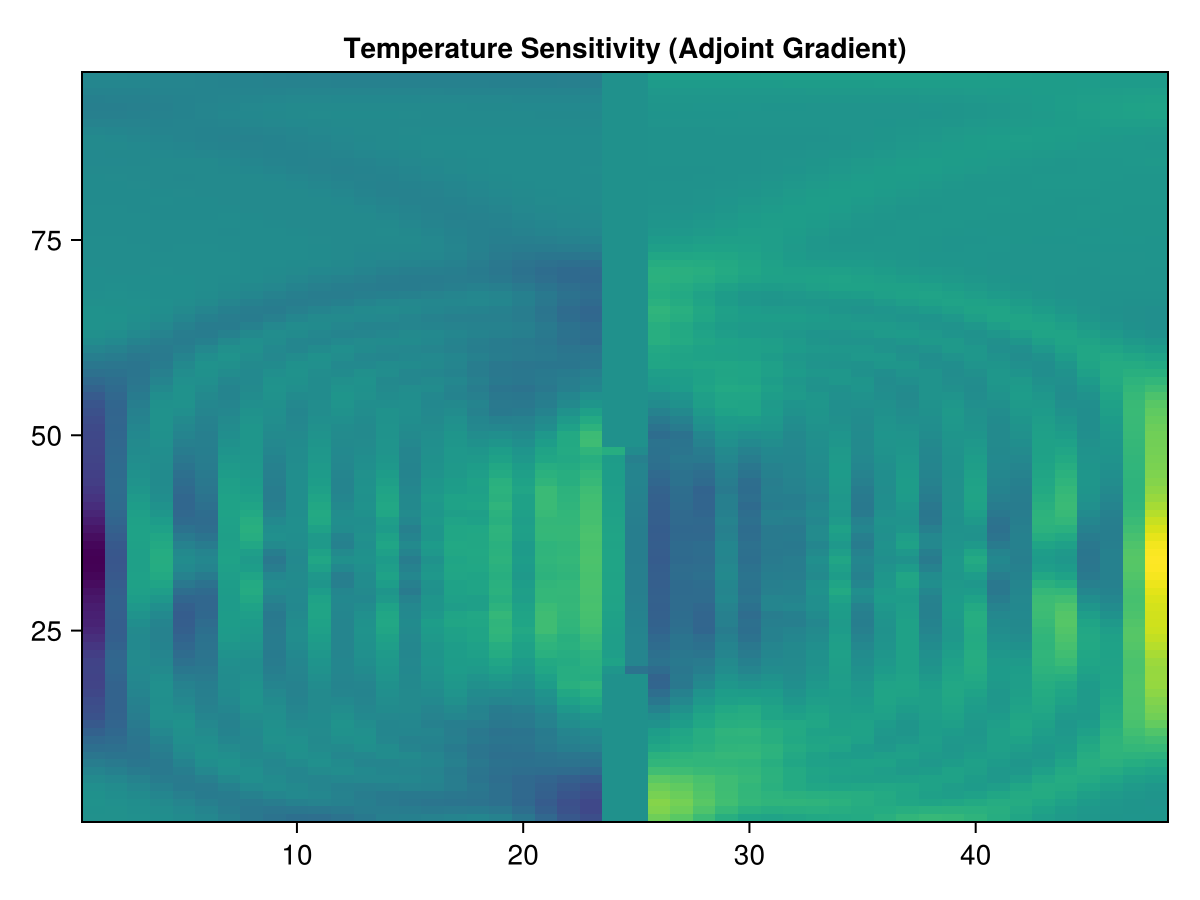

In [10]:
using CairoMakie
heatmap(Array(interior(dTᵢ, :, :, 1)), 
        axis = (title = "Temperature Sensitivity (Adjoint Gradient)",))

### 3D Volumetric Structure
To understand the vertical impact of the topography, we plot the temperature surface alongside a cross-sectional slice of the channel.

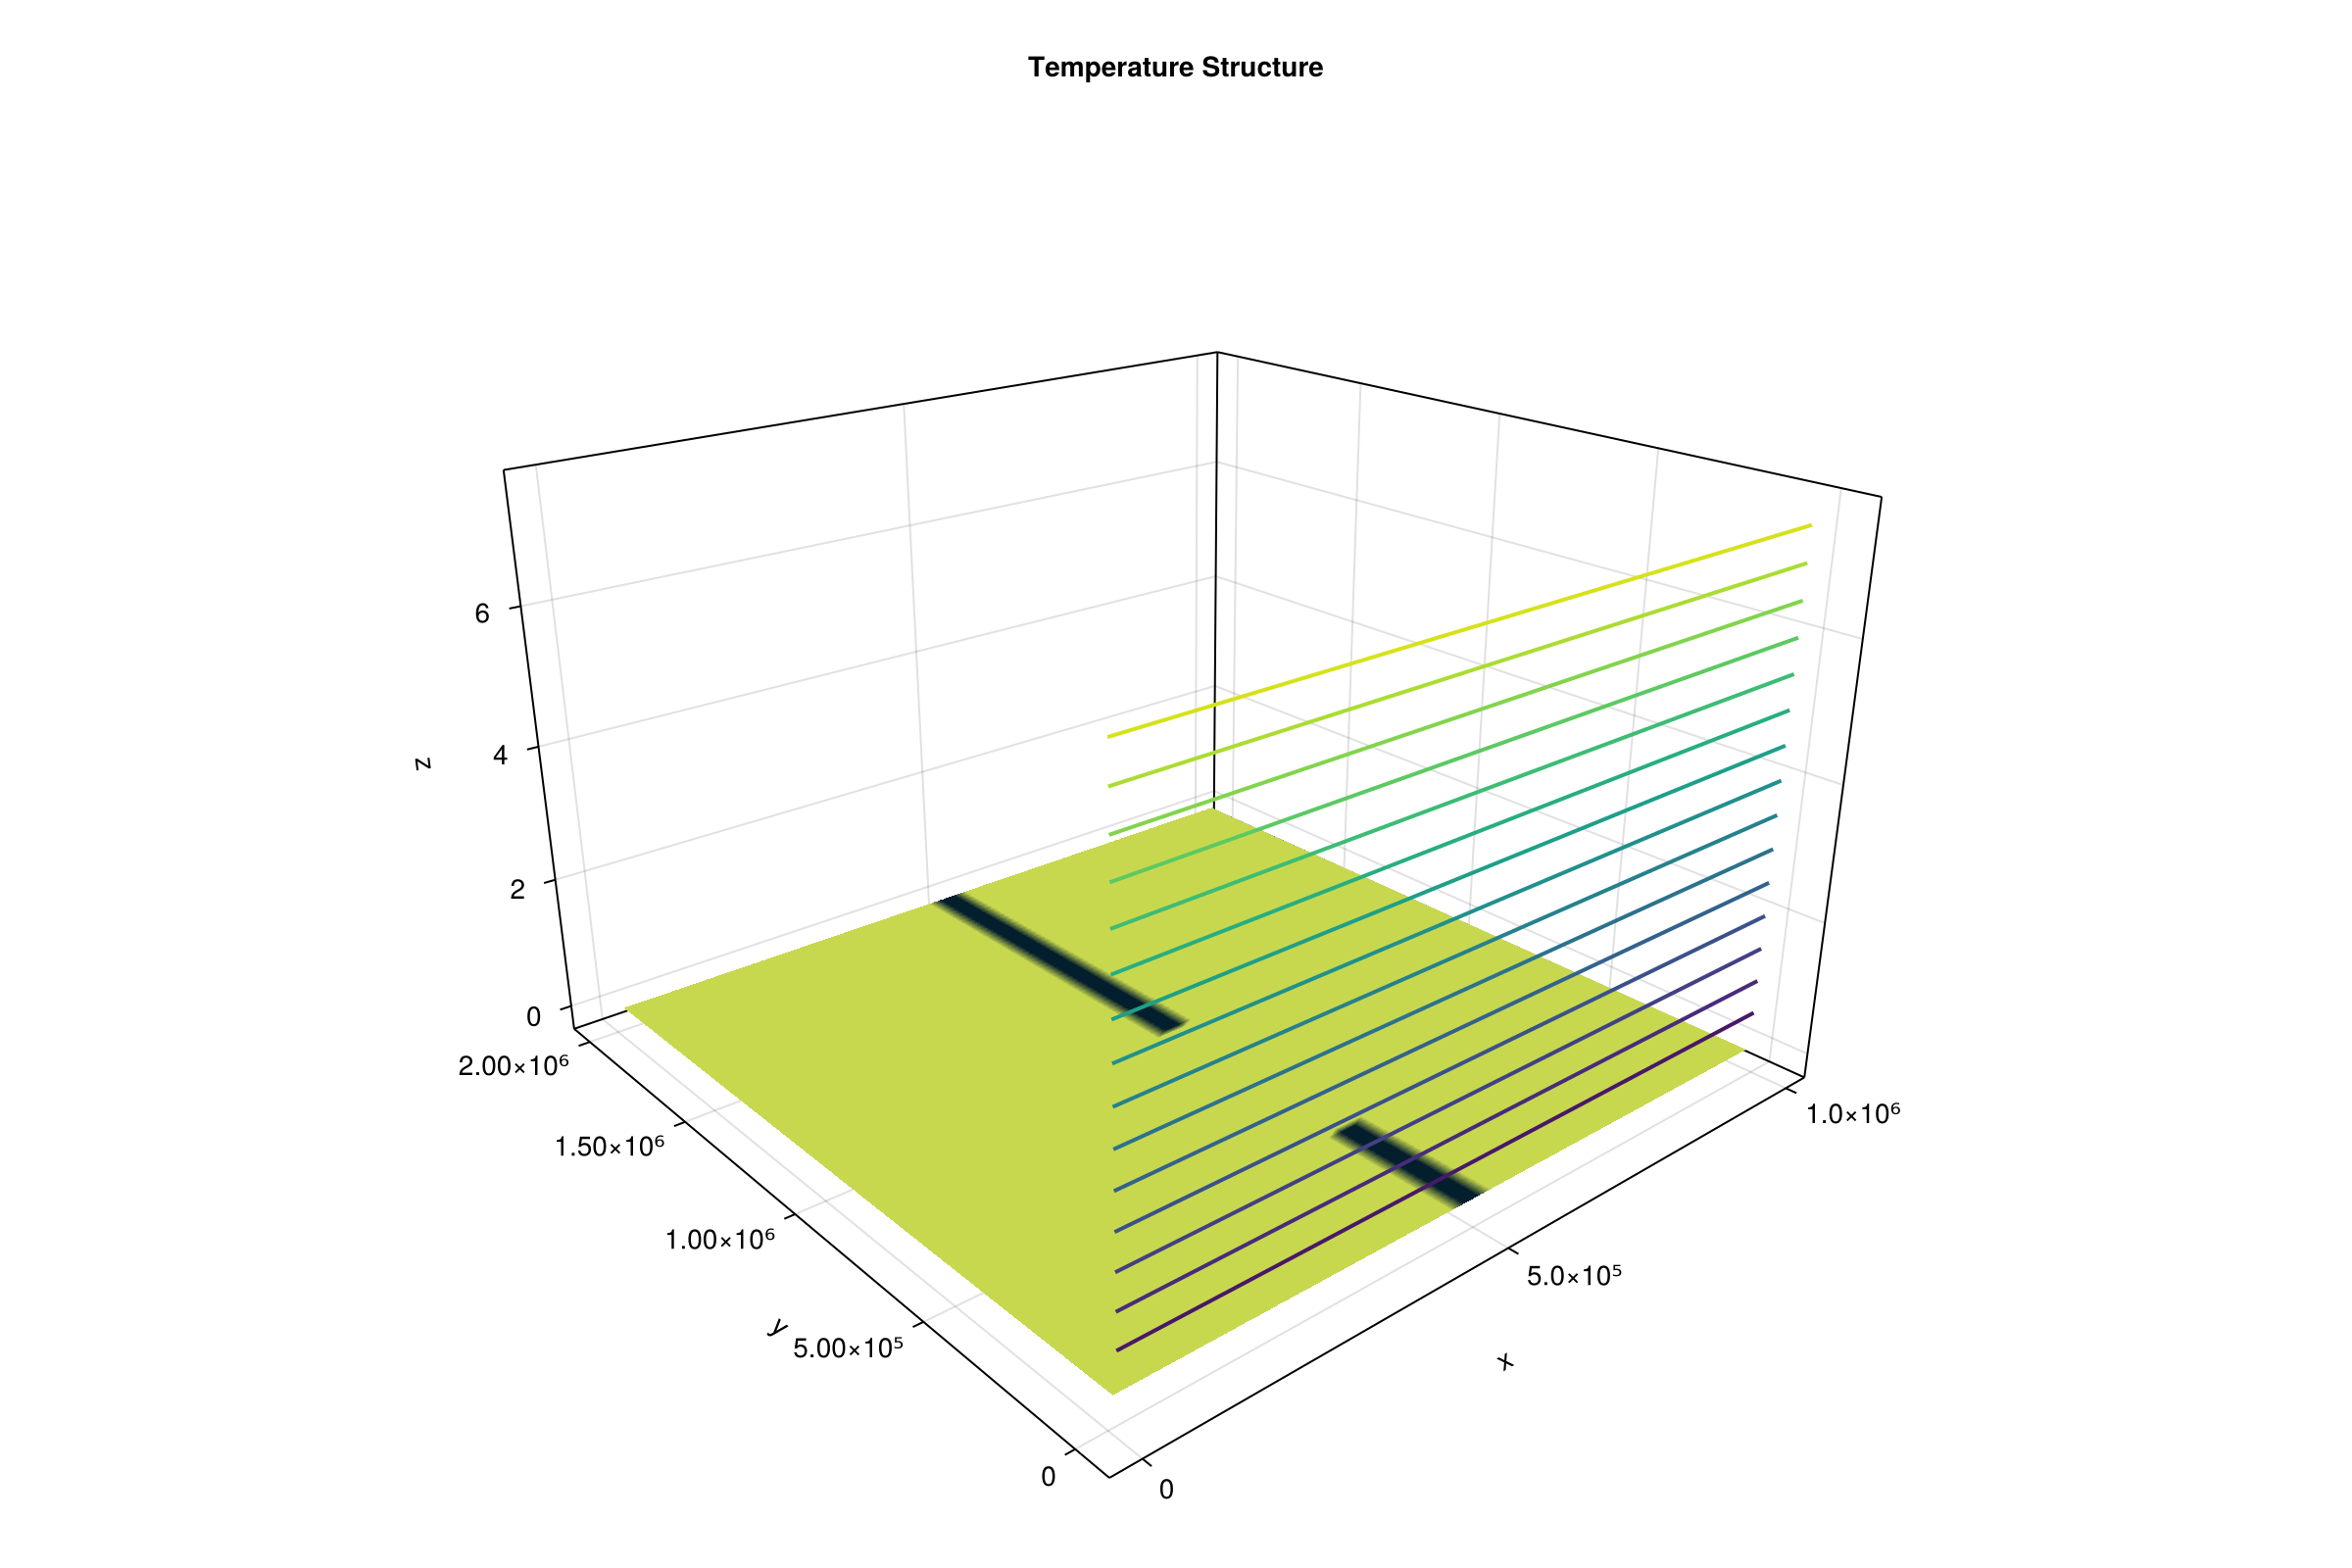

In [11]:
using CairoMakie

# 1. Prepare data
T_cpu = Array(interior(model.tracers.T, :, :, :))
x, y, z = nodes(model.tracers.T)

# 2. Create Figure
fig = Figure(size = (1200, 800))
ax = Axis3(fig[1, 1], title = "Temperature Structure", perspectiveness = 0.5)

# 3. Plot a surface and a slice
# Surface (top layer)
surface!(ax, x, y, fill(0, length(x), length(y)), color = T_cpu[:, :, end], colormap = :thermal)

# Y-Slice (middle of the channel)
mid_y = Int(floor(length(y)/2))
contour3d!(ax, x, z, T_cpu[:, mid_y, :], levels = 15, linewidth = 2)

fig

### Side-by-Side: Physics vs. Sensitivity
In this view, we compare the physical temperature field with the Adjoint sensitivity gradient ($dT/dJ$). This allows us to see if the model is most sensitive to features like thermal fronts or eddies.

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/UjJJY/src/scenes.jl:238


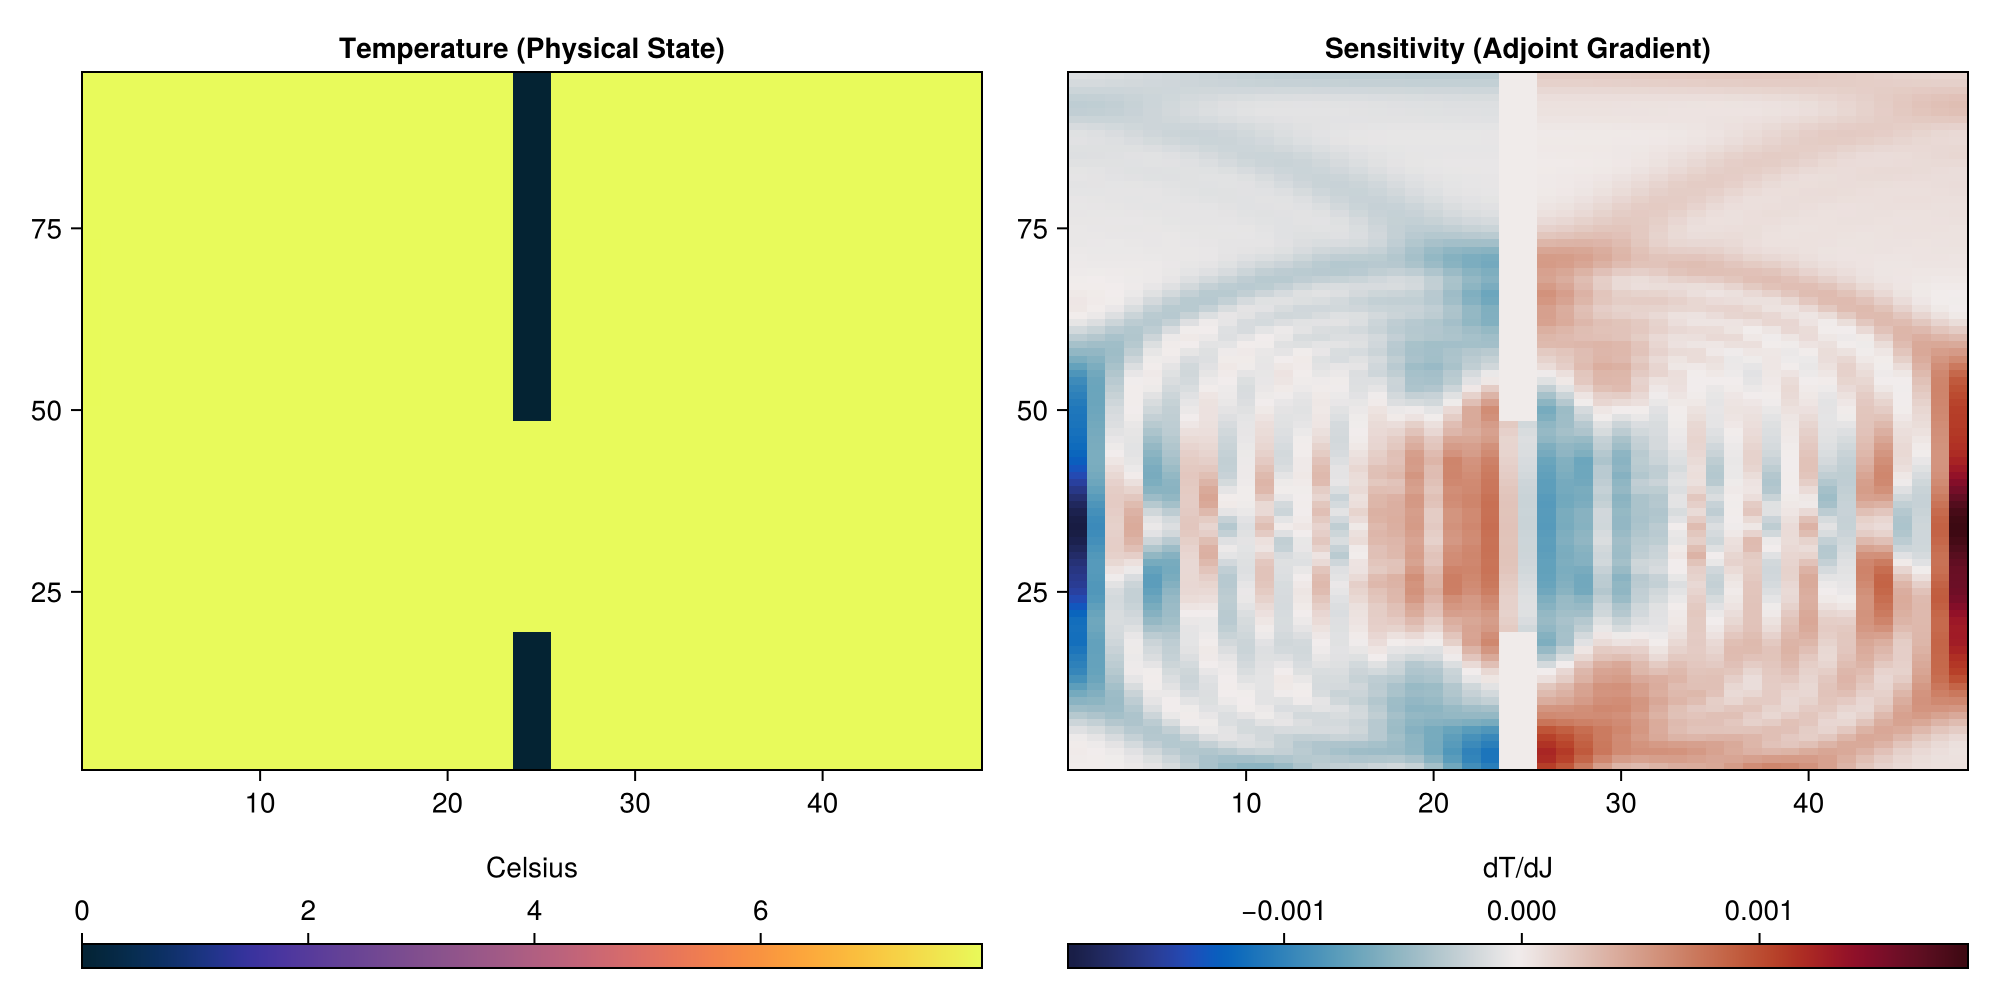

In [12]:
# 1. Get the dimensions of your grid
Nx, Ny, Nz = size(model.grid)

# 2. Pull the TOP layer (index Nz) to the CPU
T_slice = interior(model.tracers.T, :, :, Nz)
T_data  = Array(T_slice)

# 3. Pull the Gradient TOP layer
dT_slice = interior(dTᵢ, :, :, Nz)
dT_data  = Array(dT_slice)

fig = Figure(resolution = (1000, 500))

ax1 = Axis(fig[1, 1], title = "Temperature (Physical State)")
hm1 = heatmap!(ax1, T_data, colormap = :thermal)
Colorbar(fig[2, 1], hm1, vertical = false, label = "Celsius")

ax2 = Axis(fig[1, 2], title = "Sensitivity (Adjoint Gradient)")
hm2 = heatmap!(ax2, dT_data, colormap = :balance)
Colorbar(fig[2, 2], hm2, vertical = false, label = "dT/dJ")

fig

### Mixed Layer Depth (MLD) Topography
The Mixed Layer Depth represents the portion of the upper ocean that is actively "ventilated" by the atmosphere.
Plotting this helps us understand the vertical extent of surface forcing.

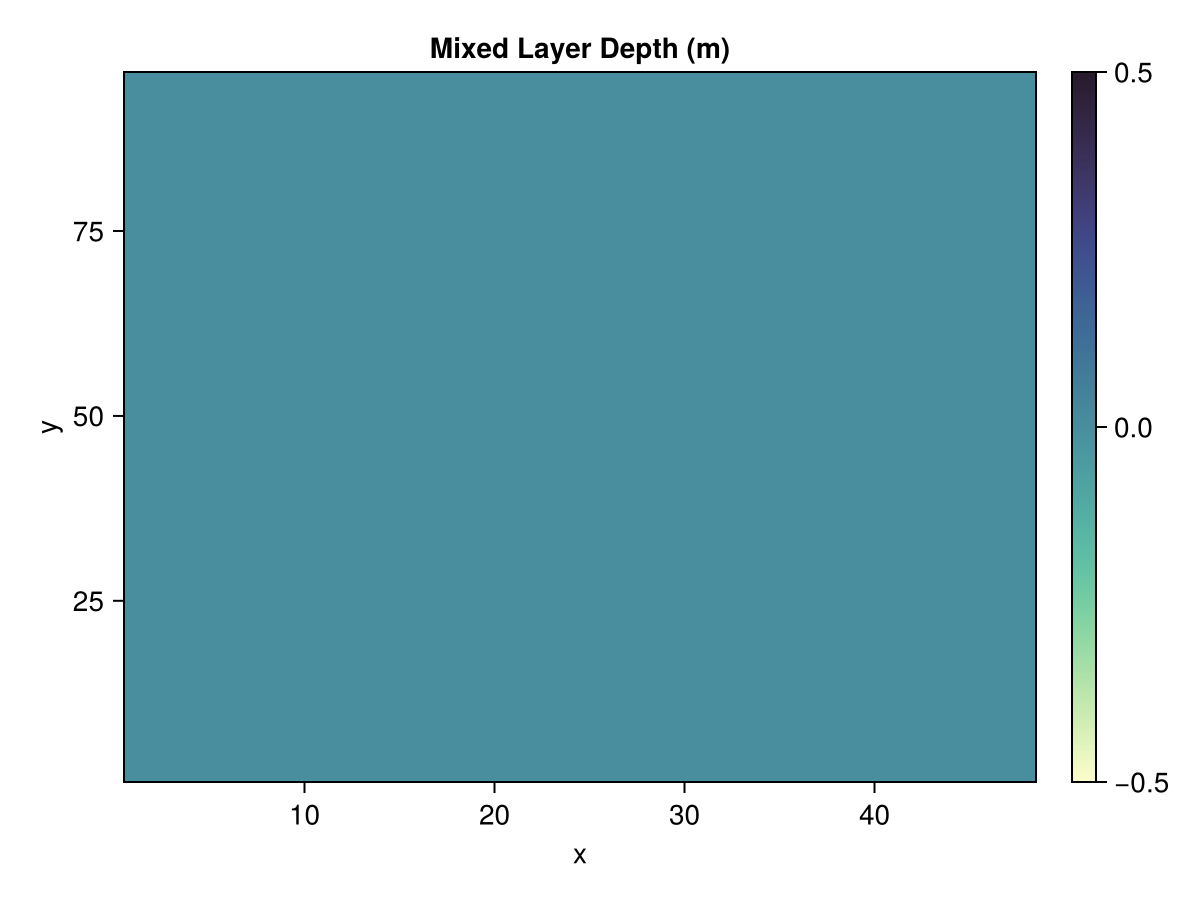

In [14]:
mld_cpu = Array(interior(mld, :, :, 1))

fig = Figure()
ax = Axis(fig[1, 1], title = "Mixed Layer Depth (m)", xlabel = "x", ylabel = "y")
hm = heatmap!(ax, mld_cpu, colormap = :deep)
contour!(ax, mld_cpu, color = :white, levels = 5, alpha = 0.5) # Add contour lines for depth
Colorbar(fig[1, 2], hm)
fig

### Surface Velocity
Finally, we visualize the surface currents. We calculate the speed magnitude and overlay velocity arrows. To keep the plot clean, we "subsample" the arrows, showing every 4th vector.

┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/UjJJY/src/basic_recipes/arrows.jl:164
┌ Warning: arrowsize has been deprecated in favor of tipwidth and tiplength.
└ @ Makie ~/.julia/packages/Makie/UjJJY/src/basic_recipes/arrows.jl:204


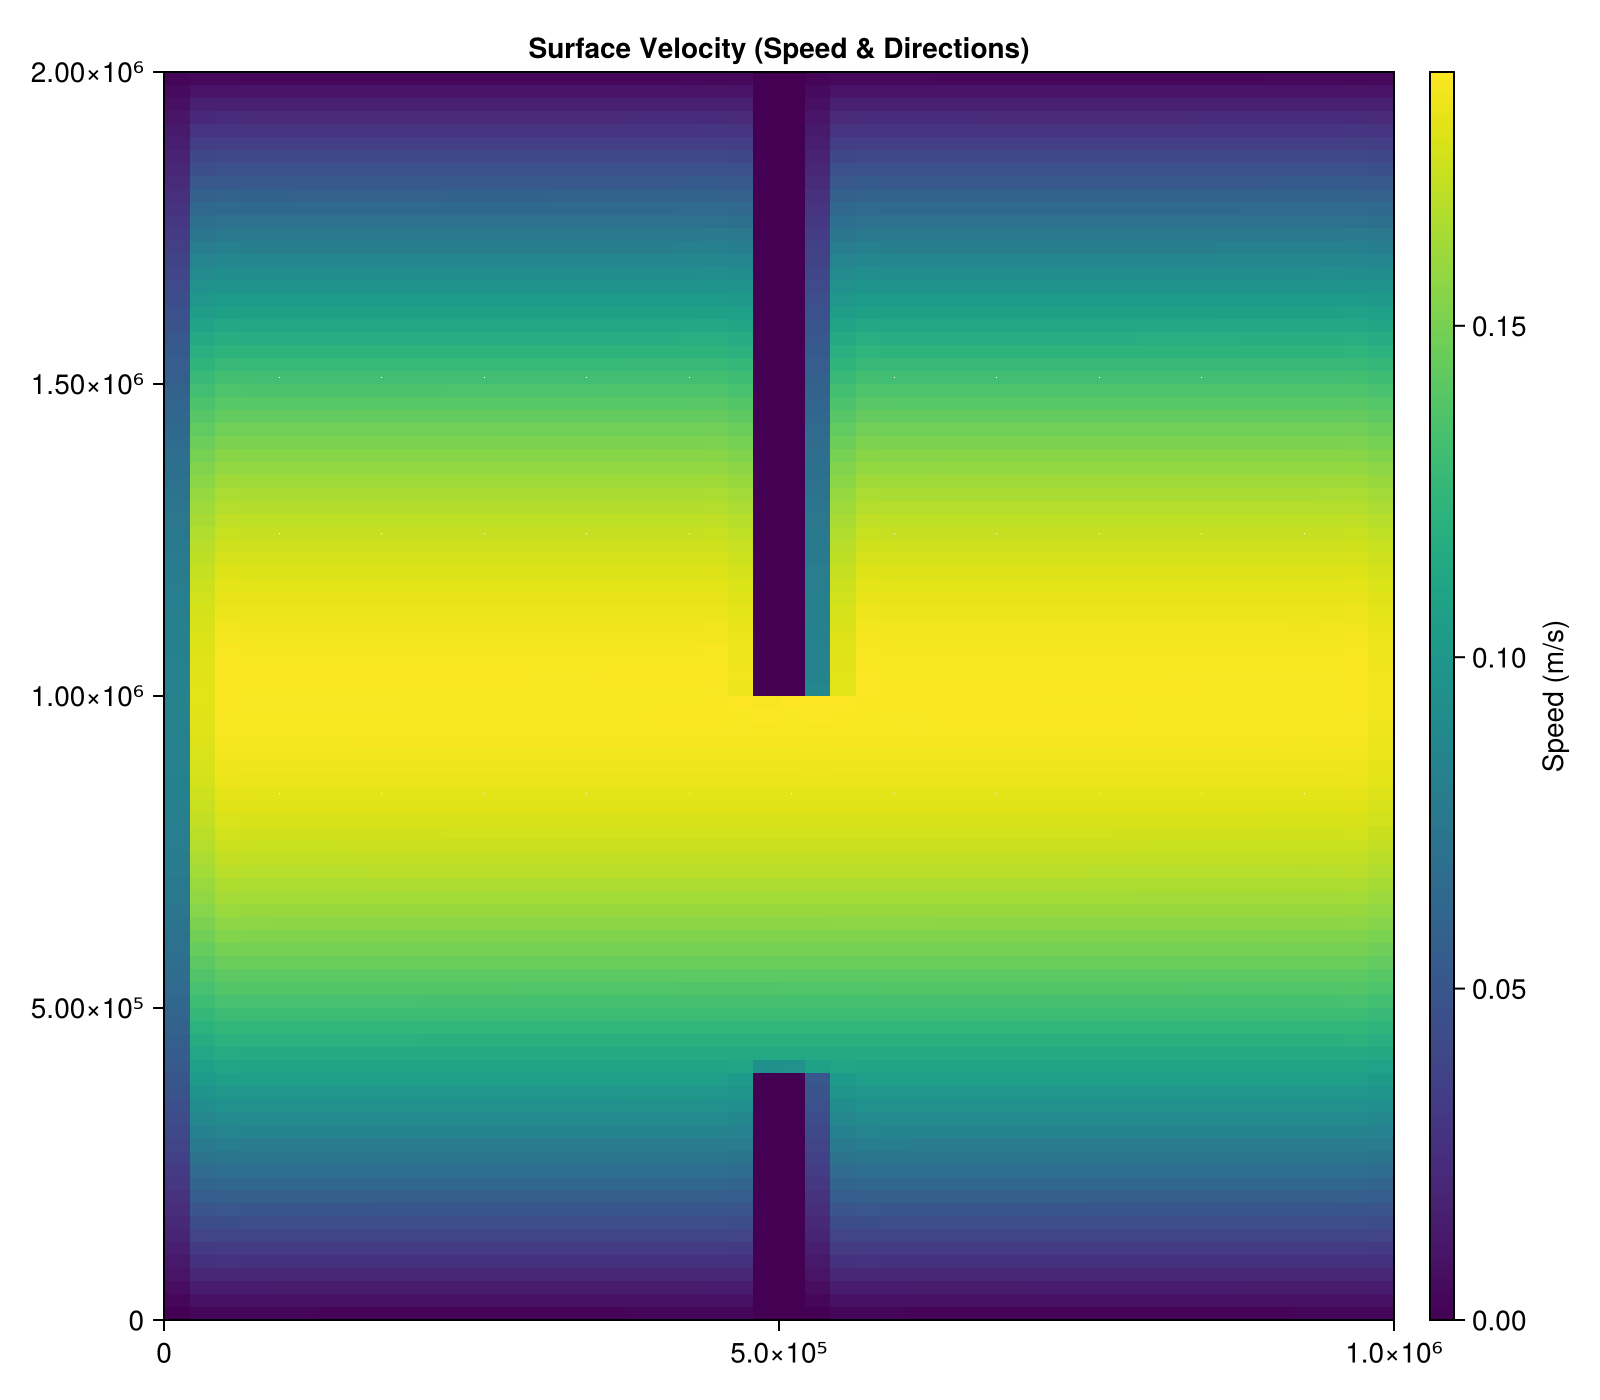

In [15]:
# 1. Get the indices and coordinates
Nx, Ny, Nz = size(model.grid)
xc, yc, zc = nodes(model.grid, Center(), Center(), Center())

# 2. Pull data to CPU
u_raw = Array(interior(model.velocities.u, :, :, Nz))
v_raw = Array(interior(model.velocities.v, :, :, Nz))

# 3. Align to common Nx, Ny grid
u_plot = u_raw[1:Nx, 1:Ny]
v_plot = v_raw[1:Nx, 1:Ny]
speed  = sqrt.(u_plot.^2 .+ v_plot.^2)

# 4. Plotting
fig = Figure(size = (800, 700))
ax = Axis(fig[1, 1], title = "Surface Velocity (Speed & Directions)")

# Background Heatmap
hm = heatmap!(ax, xc, yc, speed, colormap = :viridis)
Colorbar(fig[1, 2], hm, label = "Speed (m/s)")

# 5. Add Velocity Arrows
# We 'subsample' every 2nd or 4th arrow so the plot isn't too crowded
sub = 4 
arrows!(ax, xc[1:sub:end], yc[1:sub:end], 
        u_plot[1:sub:end, 1:sub:end], v_plot[1:sub:end, 1:sub:end], 
        lengthscale = 0.5, arrowsize = 10, color = :white)

fig

### Wind Sensitivity vs. Sea Surface Height (SSH)
This final visualization compares the **Adjoint Sensitivity** of the zonal wind stress with the **Physical State** of the Sea Surface Height (SSH). 

* **SSH (Right):** Shows the geostrophic balance of the ocean surface that drive the major currents.
* **Wind Sensitivity (Left):** Shows exactly where changing the wind stress would have the largest impact on our zonal transport objective. Notice if high-sensitivity areas align with strong SSH gradients (the jets).

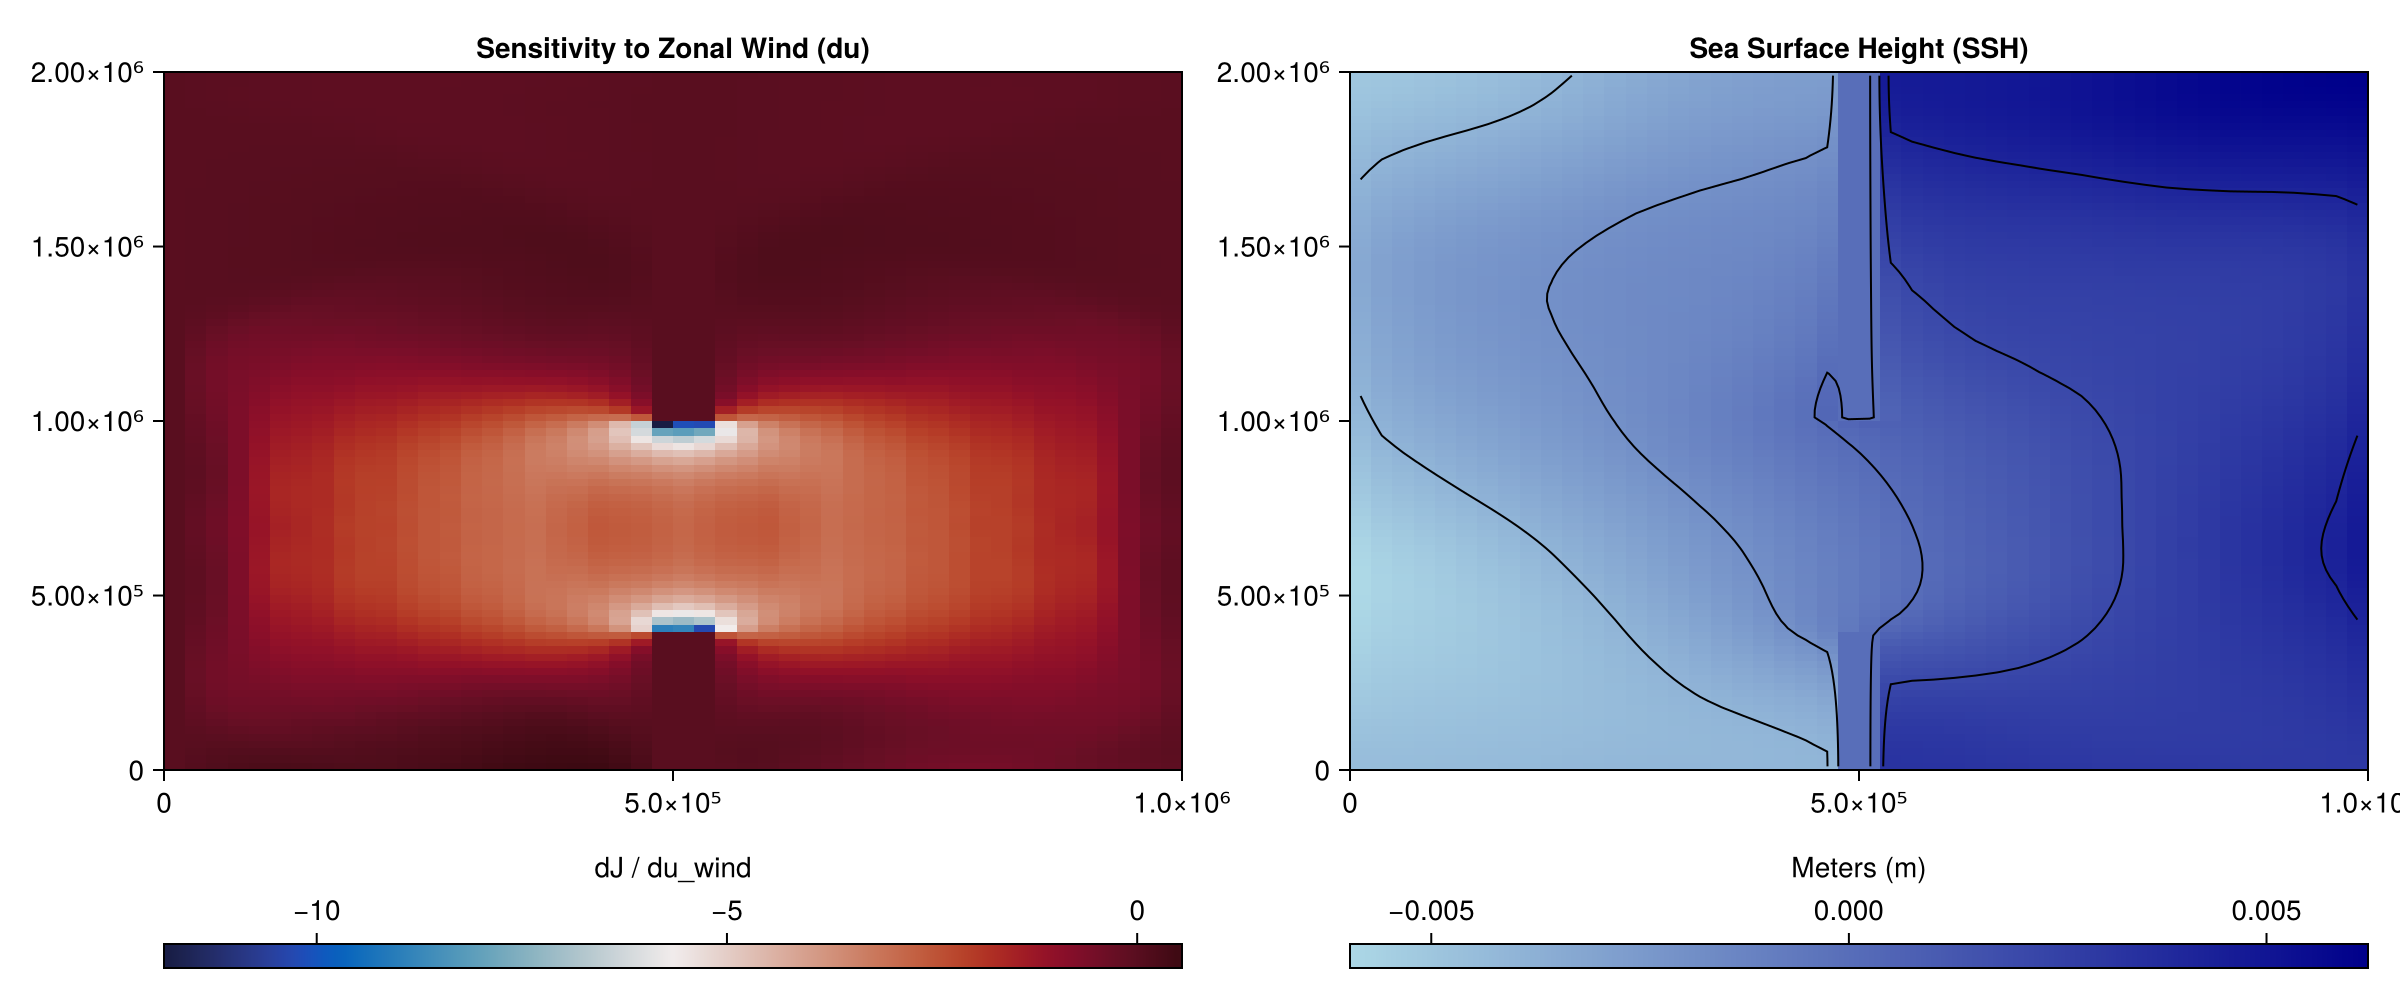

In [16]:
# 1. Pull data to CPU
du_wind = Array(interior(du_wind_stress, :, :, 1))
dv_wind = Array(interior(dv_wind_stress, :, :, 1))
ssh_data = Array(interior(model.free_surface.η, :, :, 1))

# 2. Setup Figure
fig = Figure(size = (1200, 500))

# Left Plot: Zonal Wind Sensitivity
ax1 = Axis(fig[1, 1], title = "Sensitivity to Zonal Wind (du)")
hm1 = heatmap!(ax1, xc, yc, du_wind, colormap = :balance)
Colorbar(fig[2, 1], hm1, vertical = false, label = "dJ / du_wind")

# Right Plot: Sea Surface Height (Physical State)
ax2 = Axis(fig[1, 2], title = "Sea Surface Height (SSH)")
hm2 = heatmap!(ax2, xc, yc, ssh_data, colormap = :blues)
# Add some contour lines to SSH to show the 'hills and valleys' of the ocean
contour!(ax2, xc, yc, ssh_data, color = :black, alpha = 0.4)
Colorbar(fig[2, 2], hm2, vertical = false, label = "Meters (m)")

fig

# Conclusion - The Power of Differentiable Oceanography
In this tutorial, we have moved beyond simple simulation into **Inverse Modeling**. By leveraging **Reactant.jl** and **Enzyme.jl**, we have:

1. **Simulated** a complex, eddying ocean channel with immersed boundaries.

2. **Differentiated** the entire physics engine to calculate exact gradients in a single backward pass.

3. **Visualized** how specific inputs (like wind and initial temperature) directly dictate the global zonal transport.

This workflow is the foundation for next-generation oceanography, enabling efficient parameter estimation, state estimation, and the quantification of uncertainty in climate projections.

If you are interested to play with the simulation, here are some possible steps:

- Try changing the `Ntimesteps` to see how sensitivities evolve over longer integration times.

- Modify the `ridge_function` to see how different seafloor geometries change the sensitivity "hotspots."

### Further Reading & Citations

If you want to dive deeper into the architecture of this differentiable simulation and the technology behind **Reactant.jl** and **Enzyme.jl**, we invite you to check out our recent work:

> **DJ4Earth: Differentiable, and Performance-portable Earth System Modeling via Program Transformations.** > *Moses, W.S., Cheng, G., Churavy, V., Gelbrecht, M., Klöwer, M., Kump, J., Morlighem, M., Williamson, S., Apte, D., Berg, P. and Giordano, M., 2025.* > [Authorea Preprints](https://essopenarchive.org/doi/pdf/10.22541/essoar.176314951.18114616/v1).

This paper details how we use these tools to enable differentiable, high-performance Earth System Modeling that is portable across CPUs, GPUs, and TPUs.